#Exercícios para entregar 5 (Parte 1)

###Aluno: Katlyn Ribeiro Almeida           
###Nusp:14586070

In [34]:
#imports necessarios
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statistics
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Lasso, Ridge, RidgeCV
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.pipeline import make_pipeline


In [20]:
#serao utilizados as bases pegando direto do drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


1 - Considere a base de concreto da UCI. Ajuste um modelo de regressão para predizer a variável y (Concrete compressive strength). Compare o coeficiente R2 obtido através de regressão linear múltipla, Lasso e ridge regression. Para os métodos Lasso e ridge regression, faça um gráfico de $\alpha \times$ R2 como foi feito nos exemplos anteriores. Use o código a seguir.

In [21]:
!pip install ucimlrepo
from ucimlrepo import fetch_ucirepo

# fetch dataset
concrete_compressive_strength = fetch_ucirepo(id=165)

# data (as pandas dataframes)
X = concrete_compressive_strength.data.features
y = concrete_compressive_strength.data.targets

# metadata
print(concrete_compressive_strength.metadata)

# variable information
print(concrete_compressive_strength.variables)

{'uci_id': 165, 'name': 'Concrete Compressive Strength', 'repository_url': 'https://archive.ics.uci.edu/dataset/165/concrete+compressive+strength', 'data_url': 'https://archive.ics.uci.edu/static/public/165/data.csv', 'abstract': 'Concrete is the most important material in civil engineering. The concrete compressive strength is a highly nonlinear function of age and ingredients. ', 'area': 'Physics and Chemistry', 'tasks': ['Regression'], 'characteristics': ['Multivariate'], 'num_instances': 1030, 'num_features': 8, 'feature_types': ['Real'], 'demographics': [], 'target_col': ['Concrete compressive strength'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 1998, 'last_updated': 'Sun Feb 11 2024', 'dataset_doi': '10.24432/C5PK67', 'creators': ['I-Cheng Yeh'], 'intro_paper': {'ID': 383, 'type': 'NATIVE', 'title': 'Modeling of strength of high-performance concrete using artificial neural networks', 'authors': 'I. Yeh', 'venue': 'C

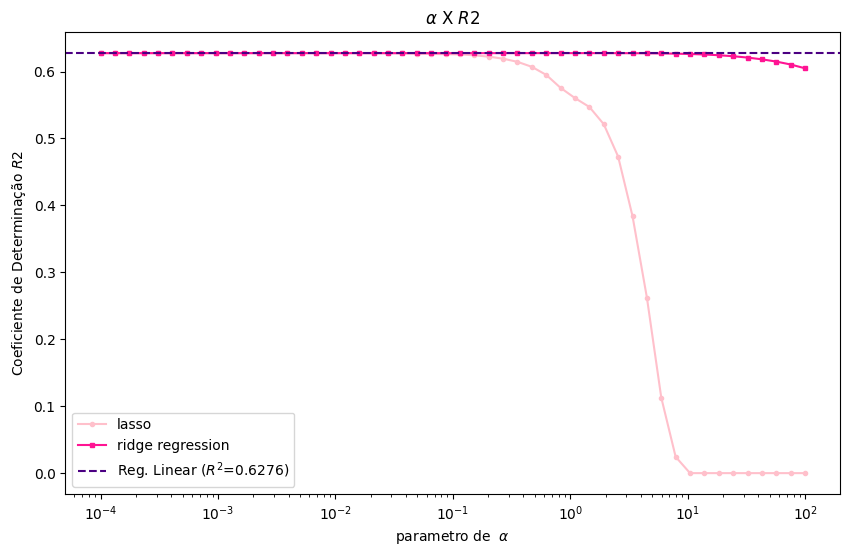

In [26]:
#codigo referente ao exercicio 1

#usarei os dados fornecidos no enunciado

#aqui acontece a divisao para o treino e para o teste
X_treino, X_teste, y_treino, y_teste = train_test_split(X, y, test_size=0.2, random_state=42)

#normalizaçao
scaler = StandardScaler()
X_treino_scaled = scaler.fit_transform(X_treino)
X_test_scaled = scaler.transform(X_teste)

#regressão linear multipla
lr = LinearRegression()
lr.fit(X_treino_scaled, y_treino)
r2_lr = r2_score(y_teste, lr.predict(X_test_scaled))

#lasso e ridge regression para diferentes valores de Alpha
alphas = np.logspace(-4, 2, 50)
lasso_scores = []
ridge_scores = []

for a in alphas:
    #lasso
    lss = Lasso(alpha=a, max_iter=10000)
    lss.fit(X_treino_scaled, y_treino)
    lasso_scores.append(r2_score(y_teste, lss.predict(X_test_scaled)))

    #ridge regression
    rg = Ridge(alpha=a)
    rg.fit(X_treino_scaled, y_treino)
    ridge_scores.append(r2_score(y_teste, rg.predict(X_test_scaled)))

#plotando o grafico---------------------------------------------------------
plt.figure(figsize=(10, 6))
plt.semilogx(alphas, lasso_scores, label='lasso', color='pink', marker='o', markersize=3)
plt.semilogx(alphas, ridge_scores, label='ridge regression', color='deeppink', marker='s', markersize=3)
plt.axhline(y=r2_lr, color='indigo', linestyle='--', label=f'Reg. Linear ($R^2$={r2_lr:.4f})')
plt.title(r'$\alpha$ X $R2$')
plt.xlabel(r'parametro de  $\alpha$')
plt.ylabel(r'Coeficiente de Determinação $R2$')
plt.legend()
plt.show()

2 - Determine as variáveis que mais influenciam a variável y (Concrete compressive strength).



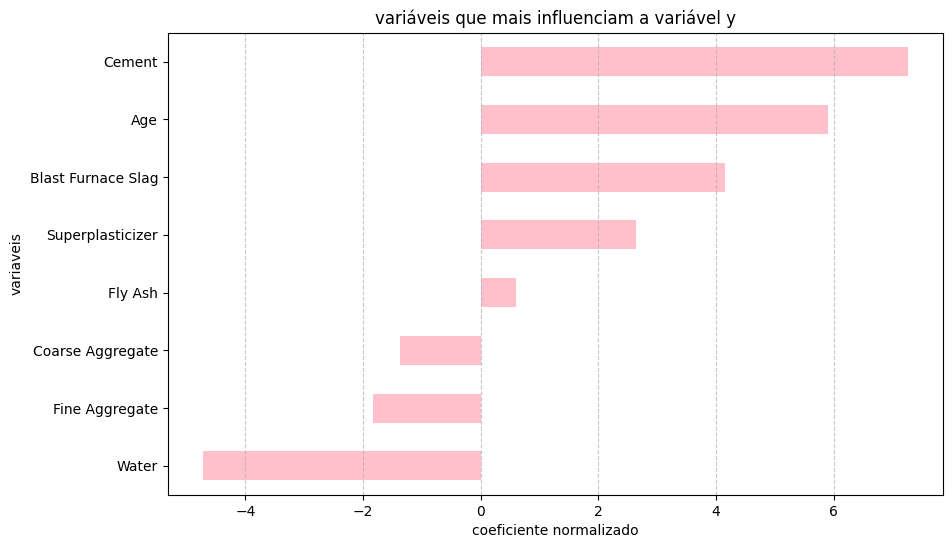

In [32]:
#codigo referente ao exercicio 2

im = pd.Series(rg.coef_, index=X.columns)
im_ordenadas = im.abs().sort_values(ascending=False)

#plotando o grafico---------------------------------------------------------
plt.figure(figsize=(10, 6))
im.sort_values().plot(kind='barh', color='pink')
plt.title('variáveis que mais influenciam a variável y')
plt.xlabel('coeficiente normalizado')
plt.ylabel('variaveis')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

3 - Considere os dados gerados com o código a seguir. Usando regularização, ajuste o grau do polinômio que define o modelo mais adequado.

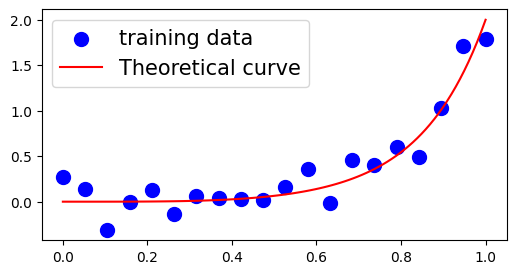

In [24]:
import numpy as np
from matplotlib import pyplot as plt

np.random.seed(10)

#função para gerar os dados
def function(x):
    y = x**4 + x**9
    return y

# training set
N_train = 20
sigma = 0.2
x_train= np.linspace(0, 1,N_train)
y_train = function(x_train) + np.random.normal(0,sigma, N_train)
x_train = x_train.reshape(len(x_train), 1)

fig = plt.figure(figsize=(6, 3))
plt.scatter(x_train, y_train, facecolor="blue", edgecolor="b",
            s=100, label="training data")

# test set
N_test = 20
x_test=np.linspace(0, 1,N_test)
y_test = function(x_test) +  np.random.normal(0,sigma, N_test)
x_test = x_test.reshape(len(x_test), 1)

# Curva teorica
xt = np.linspace(0,1,100)
yt = function(xt)
plt.plot(xt,yt, '-r',  label="Theoretical curve")
plt.legend(fontsize=15)
plt.show(True)

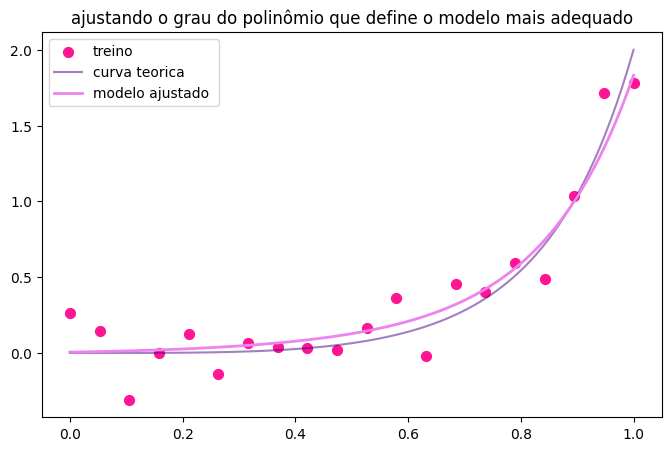

In [43]:
#codigo referente ao exercicio 3

#definição do modelo: Polinômio de Grau 10 + Ridge com busca de Alpha
grau = 10
alphas = np.logspace(-6, 1, 100)
modelo = make_pipeline(PolynomialFeatures(grau), RidgeCV(alphas=alphas, scoring='neg_mean_squared_error'))

#aqui acontece a divisao para o treino e para o teste
modelo.fit(x_train, y_train)

#prediçao
y_pred = modelo.predict(x_test)
mse = mean_squared_error(y_test, y_pred)

#plotando o grafico---------------------------------------------------------
plt.figure(figsize=(8, 5))
plt.scatter(x_train, y_train, facecolor="deeppink", edgecolor="deeppink", s=50, label="treino")
plt.plot(xt, yt, 'indigo', label="curva teorica", alpha=0.5)
y_plot = modelo.predict(xt.reshape(-1, 1))
plt.plot(xt, y_plot, 'violet', label=f"modelo ajustado ", linewidth=2)

plt.title(f"ajustando o grau do polinômio que define o modelo mais adequado")
plt.legend()
plt.show()